In [18]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

print(f"Project root: {project_root}")

Project root: c:\Users\aryap\Desktop\predictive_maintenance


Imports and Data Load

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['font.size']=11
print("Libraries imported successfully")

Libraries imported successfully


Loading data from my MySQL

In [20]:
from database.db_load import get_data_from_mysql
df=get_data_from_mysql()


⚙️  Retrieving data from MySQL...
✅ Data retrieved successfully — Shape: (10000, 14)

📋 First 3 rows:
   id product_id type  air_temperature  process_temperature  rotational_speed  \
0   1     M14860    M            298.1                308.6              1551   
1   2     L47181    L            298.2                308.7              1408   
2   3     L47182    L            298.1                308.5              1498   

   torque  tool_wear  machine_failure  twf  hdf  pwf  osf  rnf  
0    42.8          0                0    0    0    0    0    0  
1    46.3          3                0    0    0    0    0    0  
2    49.4          5                0    0    0    0    0    0  

📋 Data types:
id                       int64
product_id              object
type                    object
air_temperature        float64
process_temperature    float64
rotational_speed         int64
torque                 float64
tool_wear                int64
machine_failure          int64
twf               

Shape of Data

In [21]:
print(f"Dataset shape:{df.shape}")
print(f"Rows:{df.shape[0]}")
print(f"Columns:{df.shape[1]}")

df.head()

Dataset shape:(10000, 14)
Rows:10000
Columns:14


,id,product_id,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [22]:
print("Data types: ")
print(df.dtypes)

print(f"\n Null Values: ")
print(df.isnull().sum())

print(f"\n Duplicate rows: {df.duplicated().sum()}")

Data types: 
id                       int64
product_id              object
type                    object
air_temperature        float64
process_temperature    float64
rotational_speed         int64
torque                 float64
tool_wear                int64
machine_failure          int64
twf                      int64
hdf                      int64
pwf                      int64
osf                      int64
rnf                      int64
dtype: object

 Null Values: 
id                     0
product_id             0
type                   0
air_temperature        0
process_temperature    0
rotational_speed       0
torque                 0
tool_wear              0
machine_failure        0
twf                    0
hdf                    0
pwf                    0
osf                    0
rnf                    0
dtype: int64

 Duplicate rows: 0


In [23]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.500,2886.896,1.0,2500.75,5000.5,7500.25,10000.0
air_temperature,10000.0,300.005,2.000,295.3,298.30,300.1,301.50,304.5
process_temperature,10000.0,310.006,1.484,305.7,308.80,310.1,311.10,313.8
rotational_speed,10000.0,1538.776,179.284,1168.0,1423.00,1503.0,1612.00,2886.0
torque,10000.0,39.987,9.969,3.8,33.20,40.1,46.80,76.6
tool_wear,10000.0,107.951,63.654,0.0,53.00,108.0,162.00,253.0
machine_failure,10000.0,0.034,0.181,0.0,0.00,0.0,0.00,1.0
twf,10000.0,0.005,0.068,0.0,0.00,0.0,0.00,1.0
hdf,10000.0,0.012,0.107,0.0,0.00,0.0,0.00,1.0
pwf,10000.0,0.010,0.097,0.0,0.00,0.0,0.00,1.0


## EDA: Univariate Analysis

Distribution of all numeric sensor features

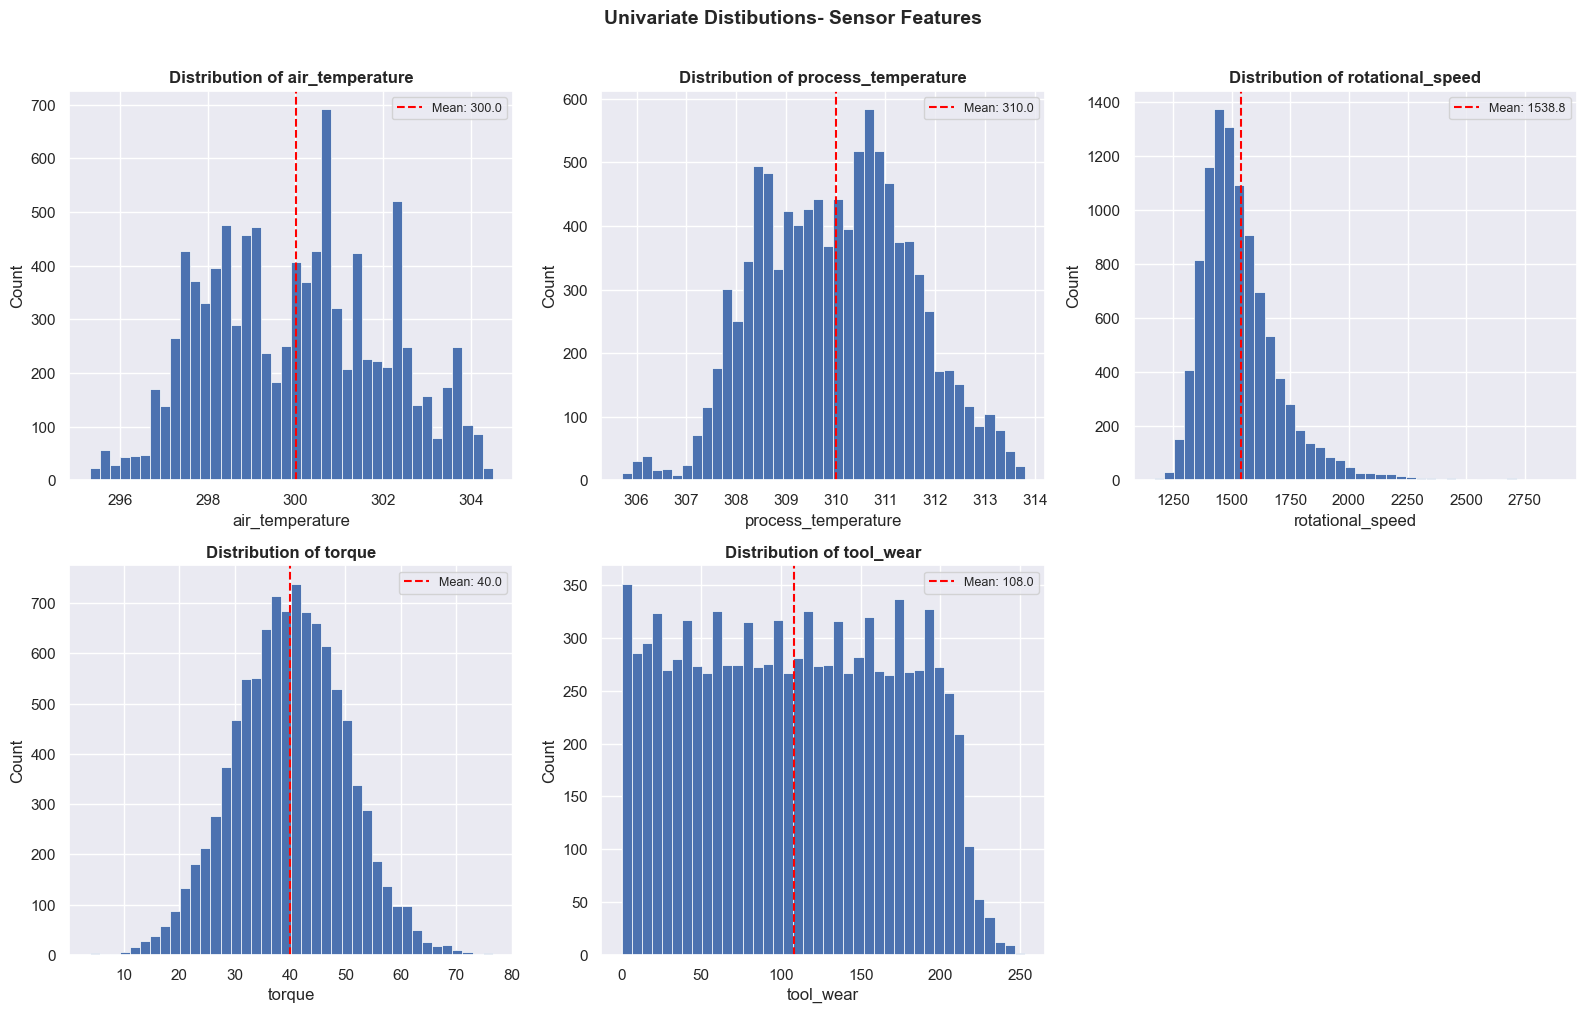

In [24]:
# important numeric sensor features
sensor_features=[
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear'
    ]
fig,axes=plt.subplots(2,3,figsize=(16,10))
axes=axes.flatten()
for i,feature in enumerate(sensor_features):
    axes[i].hist(
        df[feature],
        bins =40,
        color = '#4C72B0',
        edgecolor='white',
        linewidth=0.5
    )
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

    #add mean line
    mean_val=df[feature].mean()
    axes[i].axvline(mean_val,color='red',linestyle='--',linewidth=1.5,label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)
#hiding the 6th subplot as we have taken only 5 features for univariate analysis
axes[5].set_visible(False)

plt.suptitle('Univariate Distibutions- Sensor Features',fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/univariate_distributions.png',dpi=150,bbox_inches='tight')
plt.show()
    

Product type distribution

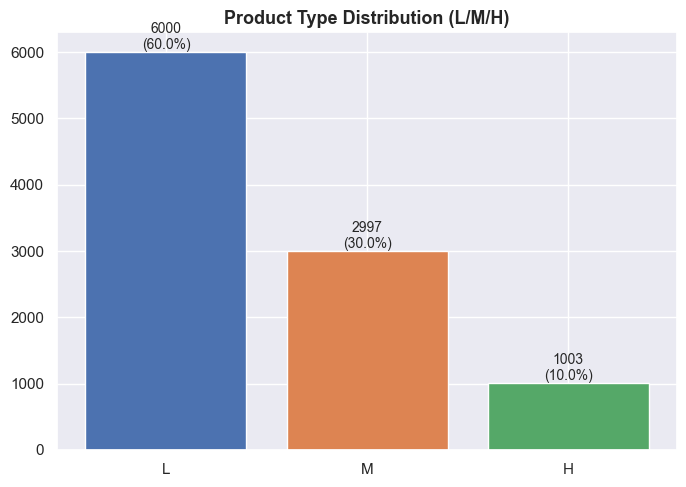

In [25]:
fig,ax=plt.subplots(figsize=(7,5))
type_counts=df['type'].value_counts()
colors=['#4C72B0','#DD8452','#55A868']

bars=ax.bar(type_counts.index,type_counts.values,color=colors,edgecolor='white')

#adding count+percentage labels on each bar
for bar,count in zip(bars,type_counts.values):
    pct=count/len(df)*100
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height() + 50,
        f'{count}\n({pct:.1f}%)',
        ha='center',fontsize=10
    )
ax.set_title('Product Type Distribution (L/M/H)',fontsize=13,fontweight='bold')
ax.set_label('Product Type')
ax.set_label('Count')
plt.tight_layout()
plt.savefig('../notebooks/product_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
#summary stats per feature
print("Sensor Feature Summary Statistics\n")
print(f"{'Feature':<25} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'Median':>8}")
print("-"*70)

for feature in sensor_features:
    print(
        f"{feature:<25}"
        f"{df[feature].min():>8.2f}"
        f"{df[feature].max():>8.2f}"
        f"{df[feature].mean():>8.2f}"
        f"{df[feature].std():>8.2f}"
        f"{df[feature].median():>8.2f}"
    )

Sensor Feature Summary Statistics

Feature                        Min      Max     Mean      Std   Median
----------------------------------------------------------------------
air_temperature            295.30  304.50  300.00    2.00  300.10
process_temperature        305.70  313.80  310.01    1.48  310.10
rotational_speed          1168.00 2886.00 1538.78  179.28 1503.00
torque                       3.80   76.60   39.99    9.97   40.10
tool_wear                    0.00  253.00  107.95   63.65  108.00


## Class Imbalance and Failure Mode Analysis

Overall machine failure distribution

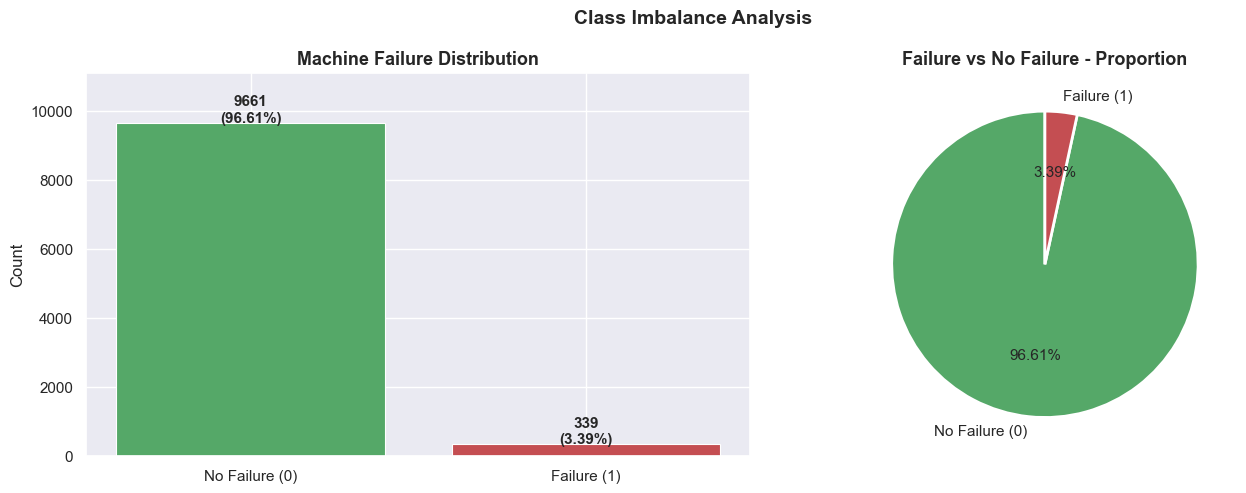


Class Imbalance Summary: 
No Failure :9661 rows (96.61%) 
Failure:339 rows (3.39%) 
Imbalance Ratio: 28.5 : 1


In [27]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

#Count bar chart
failure_counts=df['machine_failure'].value_counts()
colors=['#55A868', '#C44E52']
labels=['No Failure (0)','Failure (1)']

bars=axes[0].bar(labels,failure_counts.values,color=colors,edgecolor='white',linewidth=0.8)

for bar,count in zip(bars,failure_counts.values):
    pct=count/len(df)*100
    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+20,
        f'{count}\n({pct:.2f}%)',
        ha='center',fontsize=11,fontweight='bold'
    )

axes[0].set_title('Machine Failure Distribution',fontsize=13,fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0,max(failure_counts.values)*1.15)

#pie chart
axes[1].pie(
    failure_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[1].set_title('Failure vs No Failure - Proportion',fontsize=13,fontweight='bold')

plt.suptitle('Class Imbalance Analysis',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass Imbalance Summary: ")
print(f"No Failure :{failure_counts[0]} rows ({failure_counts[0]/len(df)*100:.2f}%) ")
print(f"Failure:{failure_counts[1]} rows ({failure_counts[1]/len(df)*100:.2f}%) ")
print(f"Imbalance Ratio: {failure_counts[0]/failure_counts[1]:.1f} : 1")


Individual failure mode breakdown:

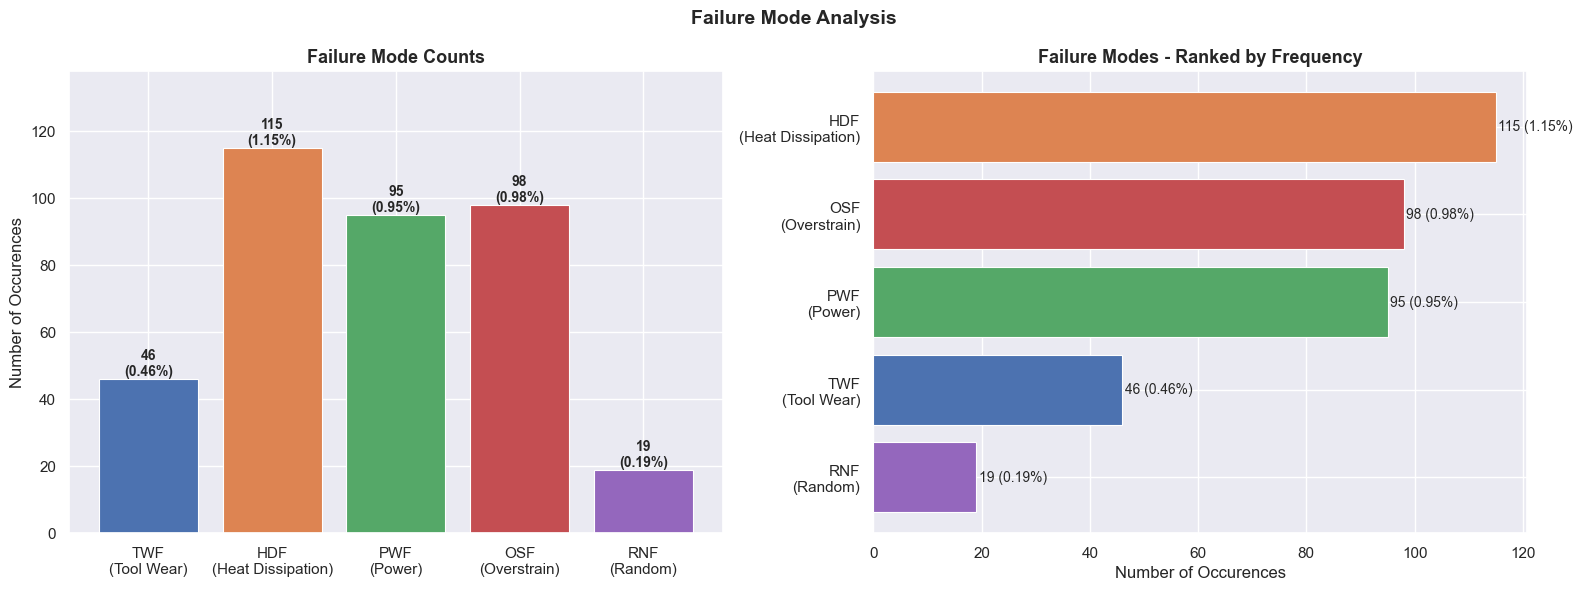

In [28]:
failure_modes=['twf','hdf','pwf','osf','rnf']
failure_labels=[
    'TWF\n(Tool Wear)',
    'HDF\n(Heat Dissipation)',
    'PWF\n(Power)',
    'OSF\n(Overstrain)',
    'RNF\n(Random)'
]
failure_colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']
failure_totals=[df[mode].sum() for mode in failure_modes]
fig,axes=plt.subplots(1,2,figsize=(16,6))

#bar chart
bars=axes[0].bar(
    failure_labels,
    failure_totals,
    color=failure_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar,count in zip(bars,failure_totals):
    pct=count/len(df)*100
    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f'{count}\n({pct:.2f}%)',
        ha='center',fontsize=10,fontweight='bold'
    )

axes[0].set_title('Failure Mode Counts',fontsize=13,fontweight='bold')
axes[0].set_ylabel('Number of Occurences')
axes[0].set_ylim(0,max(failure_totals)*1.2)

#horizontal bar chart
sorted_idx=sorted(range(len(failure_totals)),key=lambda x: failure_totals[x])
sorted_labels=[failure_labels[i] for i in sorted_idx]
sorted_totals=[failure_totals[i] for i in sorted_idx]
sorted_colors=[failure_colors[i] for i in sorted_idx]

axes[1].barh(
    sorted_labels,
    sorted_totals,
    color=sorted_colors,
    edgecolor='white',
    linewidth=0.8
)

for i,(count,label) in enumerate(zip(sorted_totals,sorted_labels)):
    pct=count/len(df)*100
    axes[1].text(
        count + 0.5,
        i,
        f'{count} ({pct:.2f}%)',
        va='center',
        fontsize=10
    )

axes[1].set_title('Failure Modes - Ranked by Frequency',fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Occurences')

plt.suptitle('Failure Mode Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/failure_mode_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Failure mode overlap analysis


Failure Mode Overlap Analysis:
Simultaneous Failures        Count   Percentage
endNo Failure                    9652       96.52%
end1 Failure Mode(s)              324        3.24%
end2 Failure Mode(s)               23        0.23%
end3 Failure Mode(s)                1        0.01%


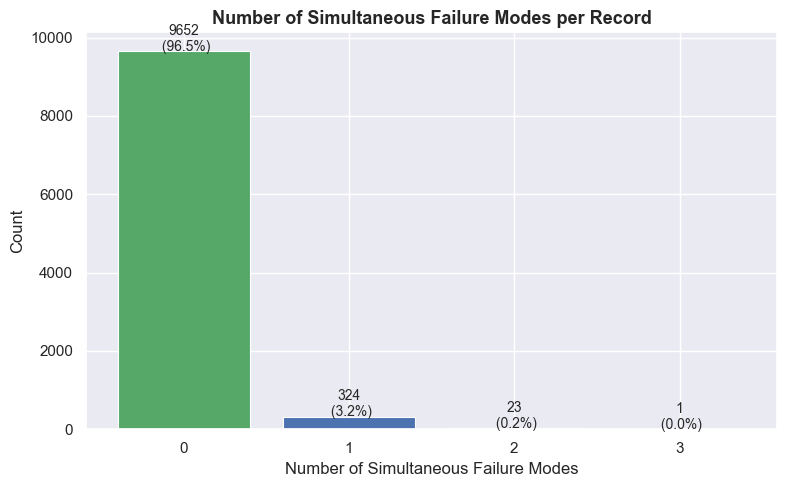

In [29]:
# how many record have multiple failure modes simultaneously
df['failure_mode_count']=df[failure_modes].sum(axis=1)
overlap_counts=df['failure_mode_count'].value_counts().sort_index()

print("\nFailure Mode Overlap Analysis:")
print(f"{'Simultaneous Failures':<25} {'Count':>8} {'Percentage':>12}")

for num_failures,count in overlap_counts.items():
    label='No Failure' if num_failures==0 \
        else f"{num_failures} Failure Mode(s)"
    print(f"end{label:<25} {count:>8} {count/len(df)*100:>11.2f}%")

#visualization
fig,ax=plt.subplots(figsize=(8,5))
colors_overlap=['#55A868', '#4C72B0', '#DD8452', '#C44E52']
bars=ax.bar(
    [str(i) for i in overlap_counts.index],
    overlap_counts.values,
    color=colors_overlap[:len(overlap_counts)],
    edgecolor='white',
    linewidth=0.8
)
for bar,count in zip(bars,overlap_counts.values):
    pct=count/len(df)*100
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+10,
        f'{count}\n ({pct:.1f}%)',
        ha='center',fontsize=10
    )

ax.set_title('Number of Simultaneous Failure Modes per Record',
             fontsize=13,fontweight='bold')
ax.set_xlabel('Number of Simultaneous Failure Modes')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../notebooks/failure_mode_overlap.png', dpi=150, bbox_inches='tight')
plt.show()











Failure rate by product type

Failure Rate by Product Type: 
Type          Total   Failures       Rate
H              1003         21      2.09%
L              6000        235      3.92%
M              2997         83      2.77%


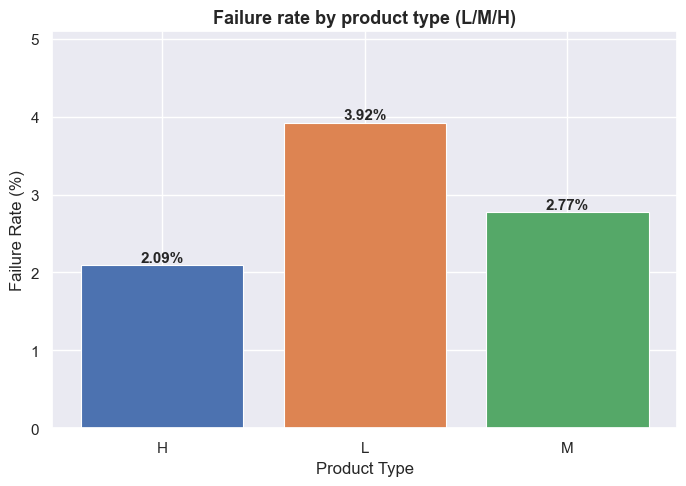

In [30]:
print("Failure Rate by Product Type: ")
print(f"{'Type':<10} {'Total':>8} {'Failures':>10} {'Rate':>10}")

type_failure=df.groupby('type')['machine_failure'].agg(['count','sum'])
type_failure['rate']=(type_failure['sum']/type_failure['count']*100).round(2)

for ptype,row in type_failure.iterrows():
    print(f"{ptype:<10} {int(row['count']):>8} {int(row['sum']):>10} {row['rate']:>9.2f}%")

#visualize
fig,ax=plt.subplots(figsize=(7,5))

bars=ax.bar(
    type_failure.index,
    type_failure['rate'],
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='white',
    linewidth=0.8
)

for bar,rate in zip(bars,type_failure['rate']):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.05,
        f'{rate:.2f}%',
        ha='center',fontsize=11,fontweight='bold'
    )
ax.set_title('Failure rate by product type (L/M/H)',
             fontsize=13,fontweight='bold')
ax.set_xlabel('Product Type')
ax.set_ylabel('Failure Rate (%)')
ax.set_ylim(0,type_failure['rate'].max()*1.3)
plt.tight_layout()
plt.savefig('../notebooks/failure_rate_by_type.png',dpi=150,bbox_inches='tight')
plt.show()

## Correlation and Bivariate Analysis

Correlation heatmap

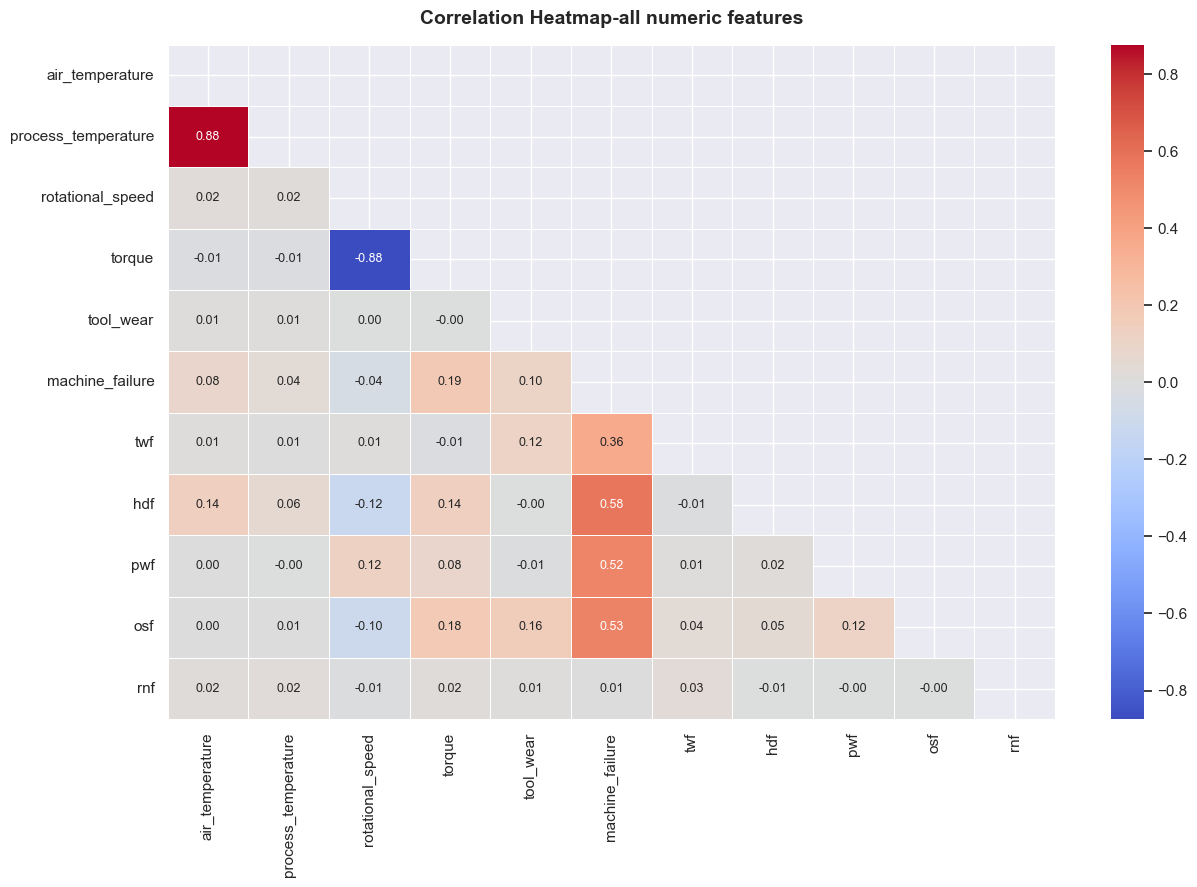

In [31]:
#select only numeric columns for correlation
numeric_cols=[
    'air_temperature','process_temperature',
    'rotational_speed','torque','tool_wear',
    'machine_failure','twf','hdf','pwf','osf','rnf'
]
corr_matrix=df[numeric_cols].corr().round(3)

fig,ax=plt.subplots(figsize=(13,9))
mask=np.triu(np.ones_like(corr_matrix,dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size':9}
    )

ax.set_title('Correlation Heatmap-all numeric features',
             fontsize=14,fontweight='bold',pad=15)
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Top correlation with machine failure

In [32]:
#isolate correlations with machine_failure only
failure_corr=corr_matrix['machine_failure'].drop('machine_failure').sort_values(
    key=lambda x:x.abs(),ascending=False
)
print("Feature Correlations with Machine Failure (sorted by absolute value): ")
print(f"{'Feature':<25} {'Correlation':>12} {'Strength':>12}")

for feature,corr_val in failure_corr.items():
    if abs(corr_val)>=0.3: strength="Strong"
    elif abs(corr_val)>=0.1:strength="Moderate"
    else: strength="Weak"
    print(f"{feature:<25} {corr_val:>12.3f} {strength:>12}")


Feature Correlations with Machine Failure (sorted by absolute value): 
Feature                    Correlation     Strength
hdf                              0.576       Strong
osf                              0.531       Strong
pwf                              0.523       Strong
twf                              0.363       Strong
torque                           0.191     Moderate
tool_wear                        0.105     Moderate
air_temperature                  0.083         Weak
rotational_speed                -0.044         Weak
process_temperature              0.036         Weak
rnf                              0.005         Weak


Boxplots: Sensor features grouped by failure

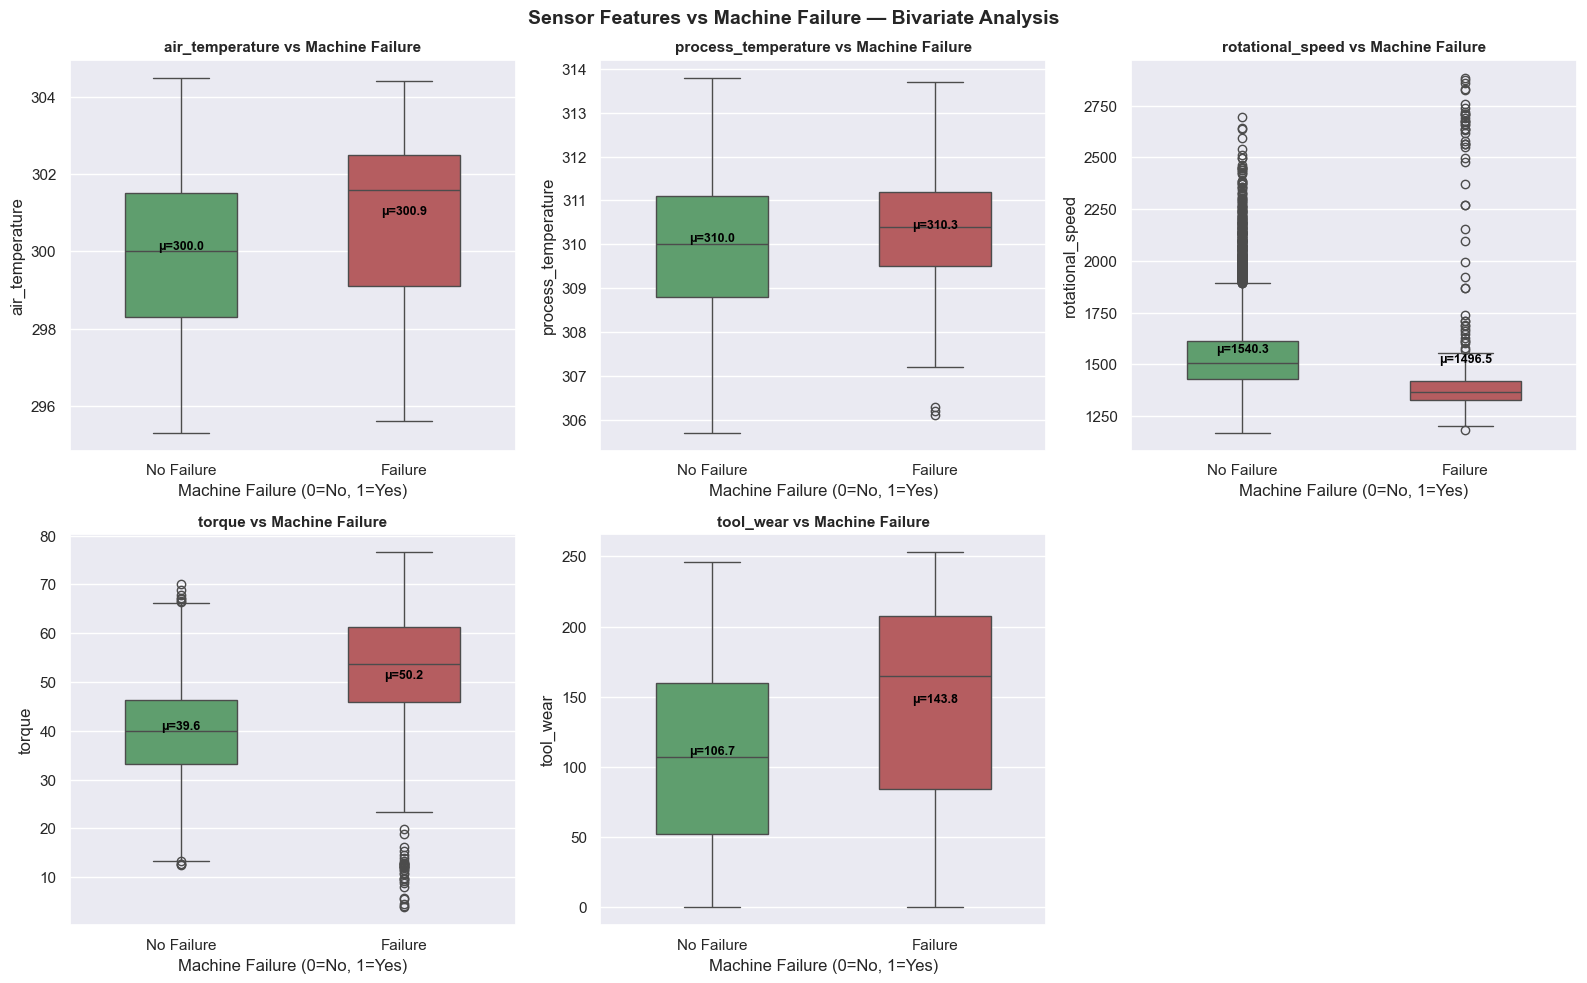

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes      = axes.flatten()

for i, feature in enumerate(sensor_features):
    sns.boxplot(
        data    = df,
        x       = 'machine_failure',
        y       = feature,
        palette = { '#55A868', '#C44E52'},
        width   = 0.5,
        ax      = axes[i]
    )

    # Calculate and annotate means
    for failure_val in [0, 1]:
        mean_val = df[df['machine_failure'] == failure_val][feature].mean()
        axes[i].text(
            failure_val, mean_val,
            f'μ={mean_val:.1f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black'
        )

    axes[i].set_title(f'{feature} vs Machine Failure',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Machine Failure (0=No, 1=Yes)')
    axes[i].set_ylabel(feature)
    axes[i].set_xticklabels(['No Failure', 'Failure'])

axes[5].set_visible(False)

plt.suptitle('Sensor Features vs Machine Failure — Bivariate Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/bivariate_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


Rotational speed vs Torque scatter coloured by failure

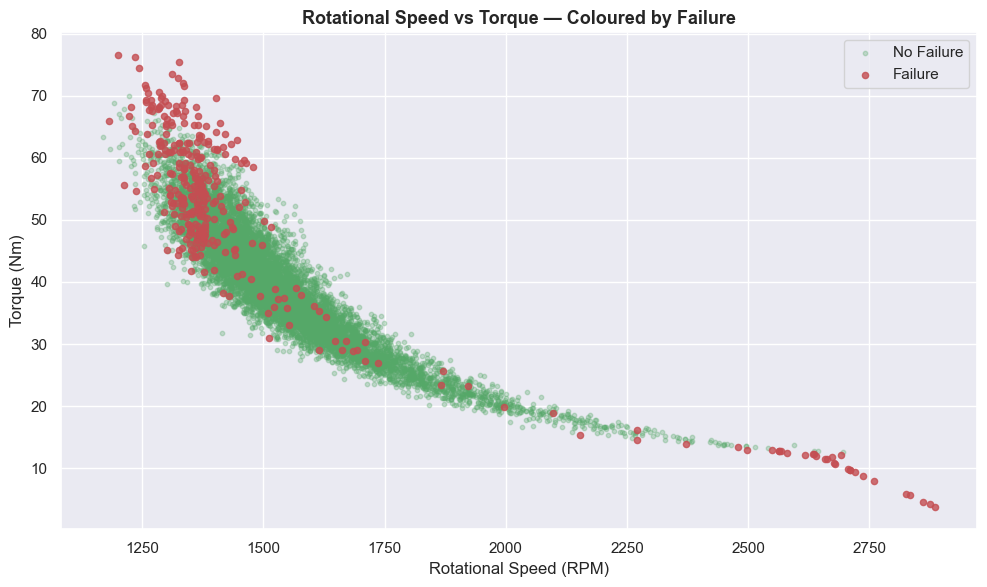

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot no-failure points first (background)
no_fail = df[df['machine_failure'] == 0]
fail    = df[df['machine_failure'] == 1]

ax.scatter(
    no_fail['rotational_speed'], no_fail['torque'],
    c='#55A868', alpha=0.3, s=10, label='No Failure'
)
ax.scatter(
    fail['rotational_speed'], fail['torque'],
    c='#C44E52', alpha=0.8, s=20, label='Failure'
)

ax.set_title('Rotational Speed vs Torque — Coloured by Failure',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Rotational Speed (RPM)')
ax.set_ylabel('Torque (Nm)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../notebooks/speed_torque_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## Tool Wear Patterns and Failure Mode Deep Dive


Tool wear distribution by failure mode

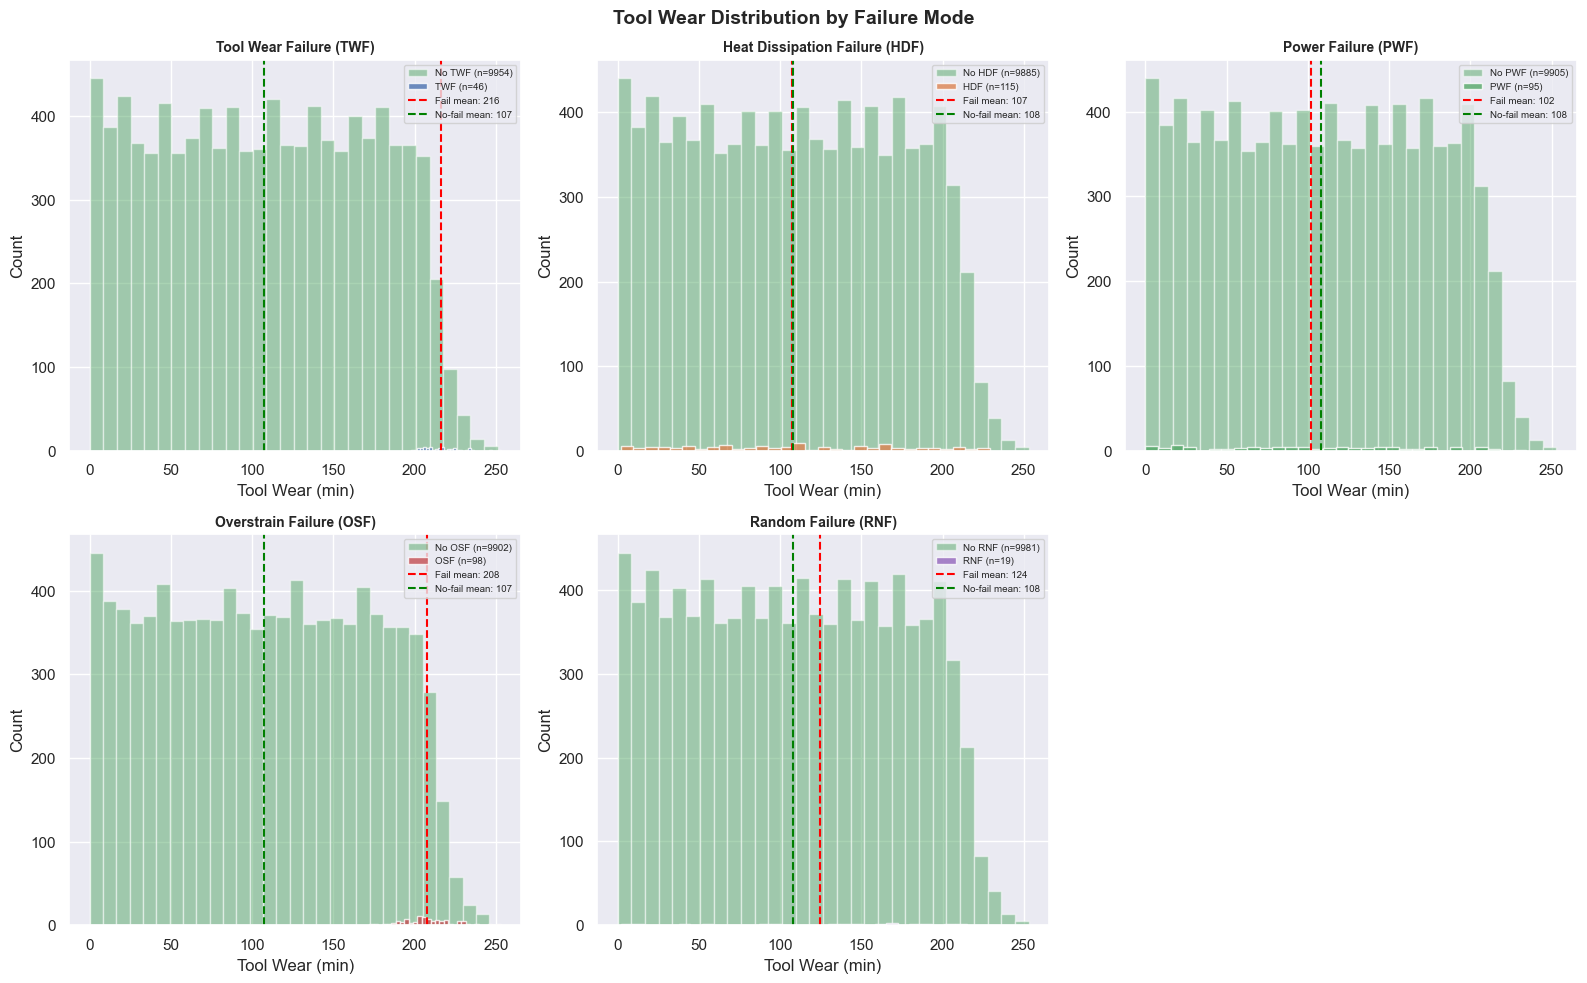

In [36]:
fig,axes=plt.subplots(2,3,figsize=(16,10))
axes=axes.flatten()

failure_mode_names={
    'twf':'Tool Wear Failure (TWF)',
    'hdf': 'Heat Dissipation Failure (HDF)',
    'pwf': 'Power Failure (PWF)',
    'osf': 'Overstrain Failure (OSF)',
    'rnf': 'Random Failure (RNF)'
}
colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']

for i,(mode,title) in enumerate (failure_mode_names.items()):
    failed=df[df[mode]==1]['tool_wear']
    not_failed=df[df[mode]==0]['tool_wear']
    
    axes[i].hist(not_failed, bins=30, alpha=0.5, color='#55A868',
                 label=f'No {mode.upper()} (n={len(not_failed)})', edgecolor='white')
    axes[i].hist(failed,     bins=30, alpha=0.8, color=colors[i],
                 label=f'{mode.upper()} (n={len(failed)})',         edgecolor='white')

    axes[i].axvline(failed.mean(),     color='red',   linestyle='--',
                    linewidth=1.5, label=f'Fail mean: {failed.mean():.0f}')
    axes[i].axvline(not_failed.mean(), color='green', linestyle='--',
                    linewidth=1.5, label=f'No-fail mean: {not_failed.mean():.0f}')

    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Tool Wear (min)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

axes[5].set_visible(False)
plt.suptitle('Tool Wear Distribution by Failure Mode',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/tool_wear_by_failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
    

Sensor means per failure mode

In [37]:
failure_modes=['twf', 'hdf', 'pwf', 'osf', 'rnf']

print("Mean Sensor Values per Failure Mode vs No Failure\n")
print(f"{'Metric':<25} {'No Fail':>10}",end="")
for mode in failure_modes:
    print(f"{mode.upper():>10}",end="")
print()

for feature in sensor_features:
    no_fail_mean=df[df['machine_failure']==0][feature].mean()
    print(f"{feature:<25} {no_fail_mean:>10.2f}",end="")
    for mode in failure_modes:
        mode_mean=df[df[mode]==1][feature].mean()
        print(f"{mode_mean:>10.2f}",end="")
    print()
    

Mean Sensor Values per Failure Mode vs No Failure

Metric                       No Fail       TWF       HDF       PWF       OSF       RNF
air_temperature               299.97    300.30    302.56    300.08    300.04    300.82
process_temperature           310.00    310.17    310.79    309.95    310.07    310.76
rotational_speed             1540.26   1566.17   1337.26   1763.97   1350.33   1485.00
torque                         39.63     37.84     53.17     48.51     58.37     43.67
tool_wear                     106.69    216.37    107.19    101.88    207.69    124.47


Temperature difference preview

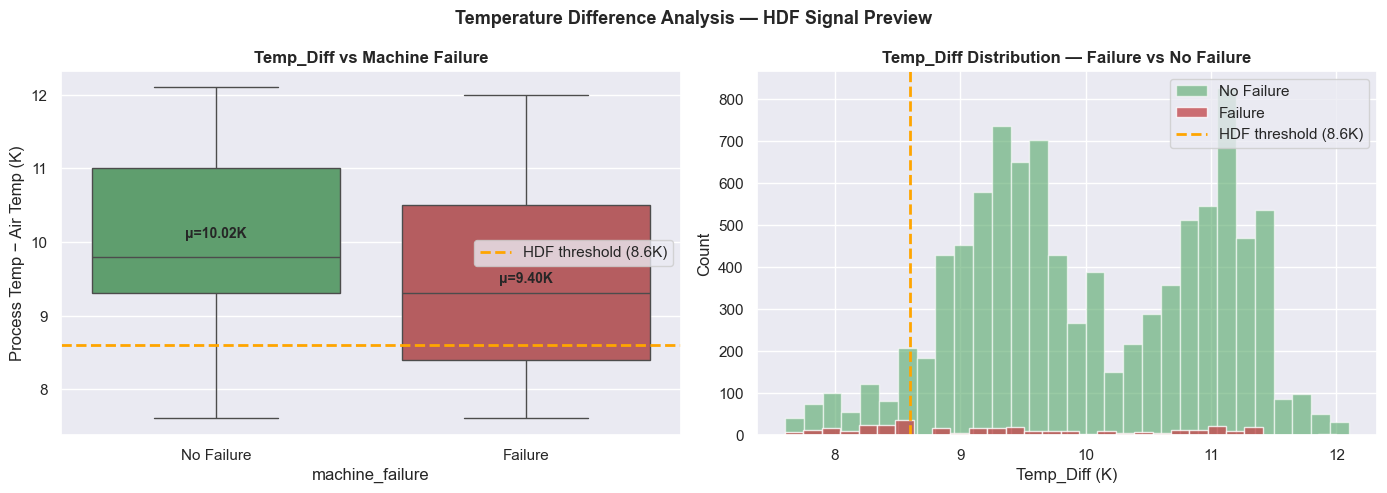

In [ ]:
#engineer Temp_Diff temporarily just for EDA visibility
df['temp_diff']=df['process_temperature']-df['air_temperature']
fig,axes=plt.subplots(1,2,figsize=(14,5))

#Temp_Diff distribution by failure 
sns.boxplot(
    data=df,
    x='machine_failure',
    y='temp_diff',
    palette=['#55A868', '#C44E52'],
    ax=axes[0]
)

for failure_val in [0,1]:
    mean_val=df[df['machine_failure']== failure_val]['temp_diff'].mean()
    axes[0].text(
        failure_val,mean_val,
        f'μ={mean_val:.2f}K',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )
axes[0].set_xticklabels(['No Failure', 'Failure'])
axes[0].set_title('Temp_Diff vs Machine Failure', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Process Temp − Air Temp (K)')
axes[0].axhline(y=8.6, color='orange', linestyle='--',
                linewidth=2, label='HDF threshold (8.6K)')
axes[0].legend()

# Temp_Diff distribution overall
axes[1].hist(df[df['machine_failure'] == 0]['temp_diff'],
             bins=30, alpha=0.6, color='#55A868', label='No Failure', edgecolor='white')
axes[1].hist(df[df['machine_failure'] == 1]['temp_diff'],
             bins=30, alpha=0.8, color='#C44E52', label='Failure',    edgecolor='white')
axes[1].axvline(x=8.6, color='orange', linestyle='--',
                linewidth=2, label='HDF threshold (8.6K)')
axes[1].set_title('Temp_Diff Distribution — Failure vs No Failure',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temp_Diff (K)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Temperature Difference Analysis — HDF Signal Preview',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/temp_diff_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Drop temp column will be properly engineered in Phase 3
df.drop(columns=['temp_diff'], inplace=True)